# **AI-Based Medical Insurance Claim Fraud Detection System**

***Step-1: Import Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from xgboost import XGBClassifier

***Step-2: Loading Dataset***

In [ ]:
df = pd.read_csv("/content/AI_Based_Medical_Insurance_Claim_Fraud_Detection_Dataset.csv")

print(df.shape)
df.head()
df.info()

(10000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   claim_id                     10000 non-null  object 
 1   patient_age                  10000 non-null  int64  
 2   patient_gender               10000 non-null  object 
 3   hospital_type                10000 non-null  object 
 4   treatment_category           10000 non-null  object 
 5   diagnosis_code               10000 non-null  object 
 6   claim_amount                 10000 non-null  float64
 7   approved_amount              10000 non-null  float64
 8   hospital_stay_days           10000 non-null  int64  
 9   previous_claims_count        10000 non-null  int64  
 10  policy_tenure_years          10000 non-null  int64  
 11  claim_submission_delay_days  10000 non-null  int64  
 12  high_risk_procedure_flag     10000 non-null  int64  
 13  docum

***Step-3: Basic EDA***

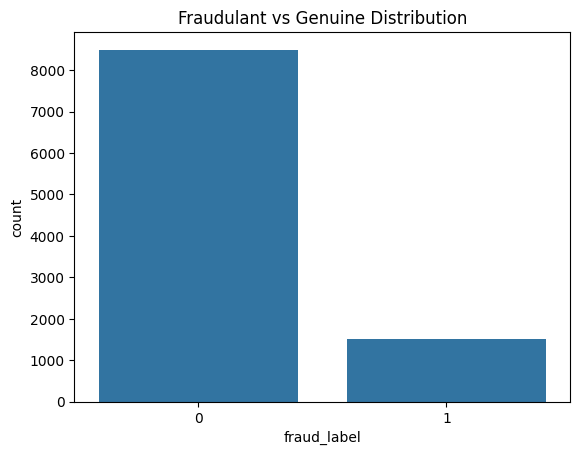

fraud_label
0    0.8498
1    0.1502
Name: proportion, dtype: float64


In [ ]:
# Fraud Detection

sns.countplot(x='fraud_label', data=df)
plt.title("Fraudulant vs Genuine Distribution")
plt.show()

print(df['fraud_label'].value_counts(normalize=True))

***Step-4: Data Pre-Processing***

In [ ]:
# Dropping Unnecessary ID

if 'claim_id' in df.columns:
    df = df.drop(columns=['claim_id'])
    print("'claim_id' column dropped.")
else:
    print("'claim_id' column already dropped or not found.")

# Encoding Categorical Variables
categorical_cols = ['patient_gender', 'hospital_type', 'treatment_category', 'diagnosis_code']

# Ensure LabelEncoder is imported
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

'claim_id' column dropped.


***Step-5: Feature/Target Split***

In [ ]:
X = df.drop('fraud_label', axis=1)
y = df['fraud_label']

***Step-6: Train-Test Split***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

***Step-7: Training Models***

In [ ]:
# 7(A). Logistic Regression (Baseline Model)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Results")
print(classification_report(y_test, log_pred))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.83      0.47      0.60      1700
           1       0.13      0.45      0.20       300

    accuracy                           0.47      2000
   macro avg       0.48      0.46      0.40      2000
weighted avg       0.73      0.47      0.54      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 7(B). SVM

from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,     # Needed for ROC
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)[:, 1]

print("SVM Classification Report")
print(classification_report(y_test, svm_pred))

SVM Classification Report
              precision    recall  f1-score   support

           0       0.84      0.26      0.40      1700
           1       0.15      0.72      0.24       300

    accuracy                           0.33      2000
   macro avg       0.49      0.49      0.32      2000
weighted avg       0.74      0.33      0.37      2000



In [ ]:
# 7(C). XGBoost

# Calculating scale_pos_weight for XGBoost
# Which is the ratio of negative class count to positive class count
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

xgb = XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:,1]

print("XGBoost Results")
print(classification_report(y_test, xgb_pred))

XGBoost Results
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1700
           1       0.17      0.13      0.14       300

    accuracy                           0.77      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.75      0.77      0.76      2000



In [ ]:

# 7(D). CatBoost

!pip install catboost
from catboost import CatBoostClassifier

# Calculate scale_pos_weight for CatBoost
# It is the ratio of negative class count to positive class count
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

cat = CatBoostClassifier(verbose=0, random_state=42, scale_pos_weight=scale_pos_weight)
cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)
cat_proba = cat.predict_proba(X_test)[:,1]

print("\nCatBoost Results")
print(classification_report(y_test, cat_pred))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00

CatBoost Results
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1700
           1       0.16      0.18      0.17       300

    accuracy                           0.73      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.75      0.73      0.74      2000



***Step-8: Model Evaluation and Detection Metrics***

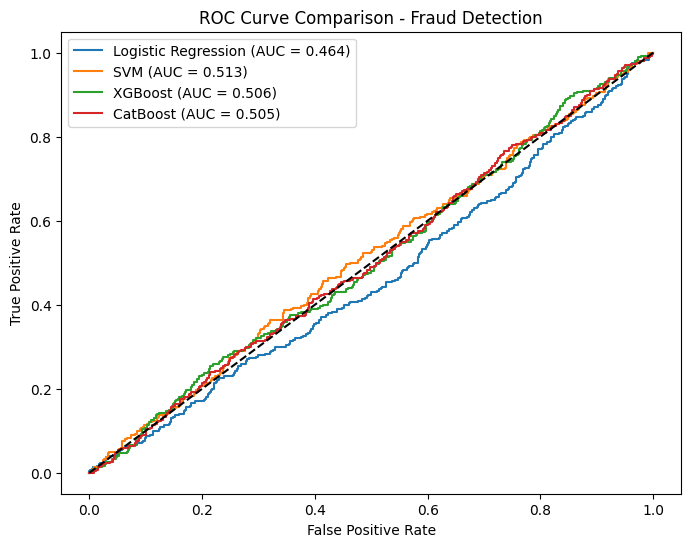

In [ ]:
# 8(A). RoC Comparison

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": log_proba,
    "SVM": svm_proba,
    "XGBoost": xgb_proba,
    "CatBoost": cat_proba
}

for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Fraud Detection")
plt.legend()
plt.show()

In [ ]:
# 8(B). Precision, Recall and F1-Score Comparison Table
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

models_pred = {
    "Logistic Regression": log_model.predict(X_test),
    "SVM": svm_model.predict(X_test),
    "XGBoost": xgb.predict(X_test),
    "CatBoost": cat.predict(X_test)
}

for name, pred in models_pred.items():
    # Use zero_division=0 to explicitly set precision/recall/f1 to 0 if there are no predicted samples
    results.append([
        name,
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0)
    ])

import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Precision", "Recall", "F1 Score"])
results_df.sort_values(by="Recall", ascending=False)

,Model,Precision,Recall,F1 Score
1,SVM,0.146540,0.720000,0.243517
0,Logistic Regression,0.131068,0.450000,0.203008
3,CatBoost,0.156977,0.180000,0.167702
2,XGBoost,0.165939,0.126667,0.143667


***Step-9: Financial Impact Analysis***

In [ ]:
# 9(A). Adding A Column (For The Claim Amount)

import numpy as np

X_test_copy = X_test.copy()
X_test_copy["Actual"] = y_test.values
X_test_copy["Predicted"] = svm_model.predict(X_test)

# Simulated claim amount
X_test_copy["claim_amount"] = np.random.randint(10000, 100000, size=len(X_test_copy))

In [ ]:
# 9(B). Calculating Financial Losses

# False Negatives = Fraud predicted as Genuine
false_negatives = X_test_copy[
    (X_test_copy["Actual"] == 1) &
    (X_test_copy["Predicted"] == 0)
]

financial_loss = false_negatives["claim_amount"].sum()

print("Total Financial Loss due to Missed Fraud: ₹", financial_loss)

Total Financial Loss due to Missed Fraud: ₹ 4180890


In [ ]:
# 9(C). Financial Analysis
import pandas as pd

financial_analysis_df = pd.DataFrame({
    'claim_amount': X_test['claim_amount'],
    'Actual': y_test
}).copy()

print("Financial Analysis DataFrame created successfully.")
print(financial_analysis_df.head())
print("\nValue counts for 'Actual' column:")
print(financial_analysis_df['Actual'].value_counts())

Financial Analysis DataFrame created successfully.
      claim_amount  Actual
5929     134181.41       0
8974     378122.65       0
7915      79280.59       0
8941     230902.55       0
5209     398474.96       0

Value counts for 'Actual' column:
Actual
0    1700
1     300
Name: count, dtype: int64


In [ ]:
# 9(D). Financial Impact Analysis

results_financial = []

models_for_financial_analysis = {
    "Logistic Regression": log_model,
    "SVM": svm_model,
    "XGBoost": xgb,
    "CatBoost": cat
}

for name, model in models_for_financial_analysis.items():
    # Making predictions
    predictions = model.predict(X_test)

    # Creating temporary DataFrame for this model's analysis
    temp_df = financial_analysis_df.copy()
    temp_df['Predicted'] = predictions

    # Calculating False Negatives (Fraud (Actual=1) predicted as Non-Fraud (Predicted=0))
    false_negatives = temp_df[(temp_df['Actual'] == 1) & (temp_df['Predicted'] == 0)]
    financial_loss = false_negatives['claim_amount'].sum()

    # Calculating True Positives (Fraud (Actual=1) predicted as Fraud (Predicted=1))
    true_positives = temp_df[(temp_df['Actual'] == 1) & (temp_df['Predicted'] == 1)]
    fraud_prevented = true_positives['claim_amount'].sum()

    results_financial.append([name, financial_loss, fraud_prevented])

financial_summary_df = pd.DataFrame(results_financial, columns=["Model", "Total Financial Loss (FN)", "Total Fraud Prevented (TP)"])
financial_summary_df_sorted = financial_summary_df.sort_values(by="Total Fraud Prevented (TP)", ascending=False)

print("\nFinancial Impact Analysis of Models:")
print(financial_summary_df_sorted)


Financial Impact Analysis of Models:
                 Model  Total Financial Loss (FN)  Total Fraud Prevented (TP)
1                  SVM                22222707.58                 56052324.94
0  Logistic Regression                46807409.84                 31467622.68
3             CatBoost                63376408.55                 14898623.97
2              XGBoost                68887890.84                  9387141.68


***Step-10: Threshold Optimization***

In [ ]:
# 10(A). Threshold Optimizations

from sklearn.metrics import precision_score, recall_score, f1_score

best_f1 = 0
best_threshold_svm = 0

# Iterate over a range of thresholds, starting from 0.01 to avoid extreme zero-thresholds
for threshold in np.arange(0.01, 1, 0.01):
    # Apply threshold to SVM probabilities
    svm_custom_pred = (svm_proba > threshold).astype(int)

    # Calculate F1-score for the positive class (fraud=1)
    f1 = f1_score(y_test, svm_custom_pred, zero_division=0)

    # Update best threshold if current F1-score is higher
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_svm = threshold

print(f"SVM Optimal Threshold for F1-score (excluding 0.00): {best_threshold_svm:.2f}")

# Evaluate SVM with the optimal threshold
svm_optimized_pred = (svm_proba > best_threshold_svm).astype(int)

print("\nSVM Classification Report with Optimal Threshold")
print(classification_report(y_test, svm_optimized_pred, zero_division=0))

SVM Optimal Threshold for F1-score (excluding 0.00): 0.01

SVM Classification Report with Optimal Threshold
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1700
           1       0.15      1.00      0.26       300

    accuracy                           0.15      2000
   macro avg       0.07      0.50      0.13      2000
weighted avg       0.02      0.15      0.04      2000



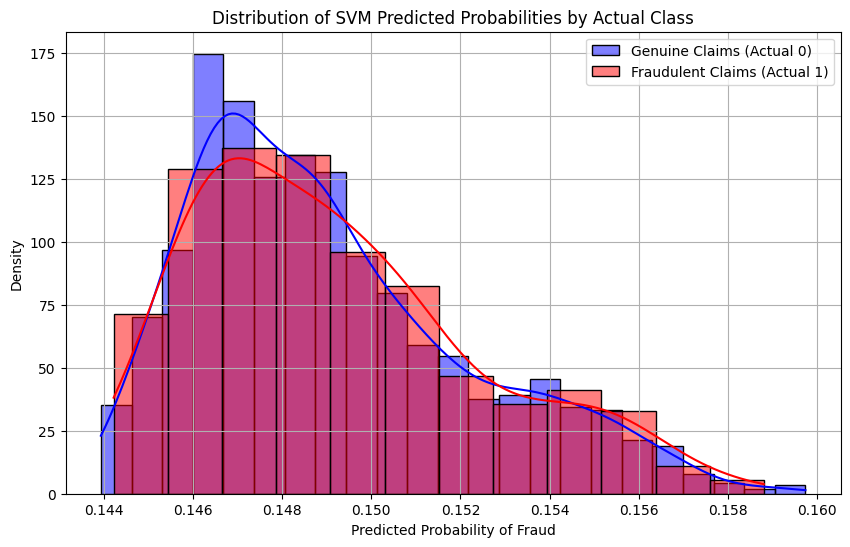

In [ ]:
# 10(B)Analysis of SVM Probability Distribution

plt.figure(figsize=(10, 6))
sns.histplot(svm_proba[y_test == 0], color='blue', label='Genuine Claims (Actual 0)', kde=True, stat='density', alpha=0.5)
sns.histplot(svm_proba[y_test == 1], color='red', label='Fraudulent Claims (Actual 1)', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of SVM Predicted Probabilities by Actual Class')
plt.xlabel('Predicted Probability of Fraud')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

***Step-11: Comprehensive Visualizations***

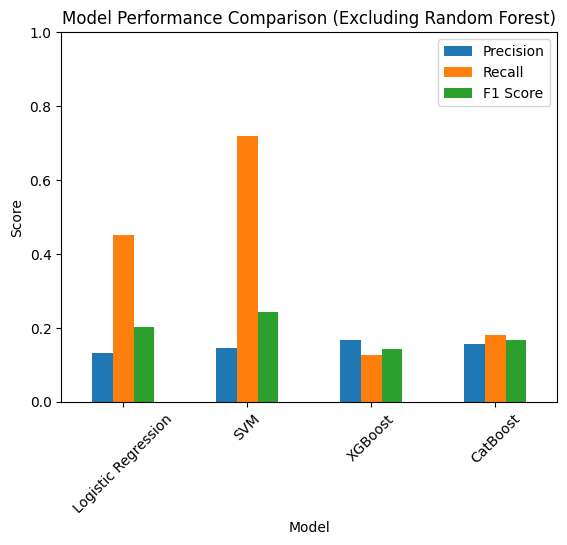

In [ ]:
# 11(A). Model Performance Comparison Chart

import matplotlib.pyplot as plt

results_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(kind="bar")
plt.title("Model Performance Comparison (Excluding Random Forest)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

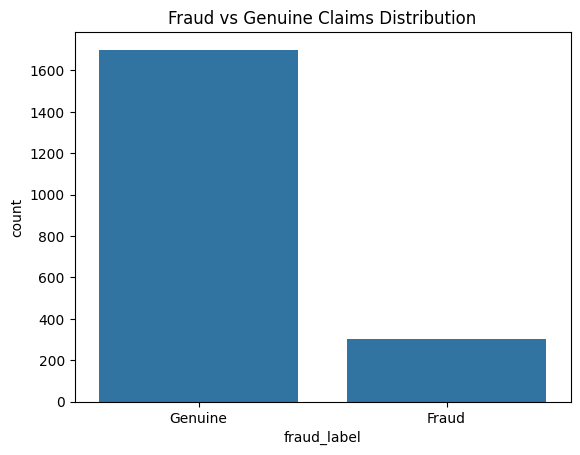

In [ ]:
# 11(B). Fraudulant V/s Genuine Distribution

import seaborn as sns

sns.countplot(x=y_test)
plt.title("Fraud vs Genuine Claims Distribution")
plt.xticks([0,1], ["Genuine", "Fraud"])
plt.show()

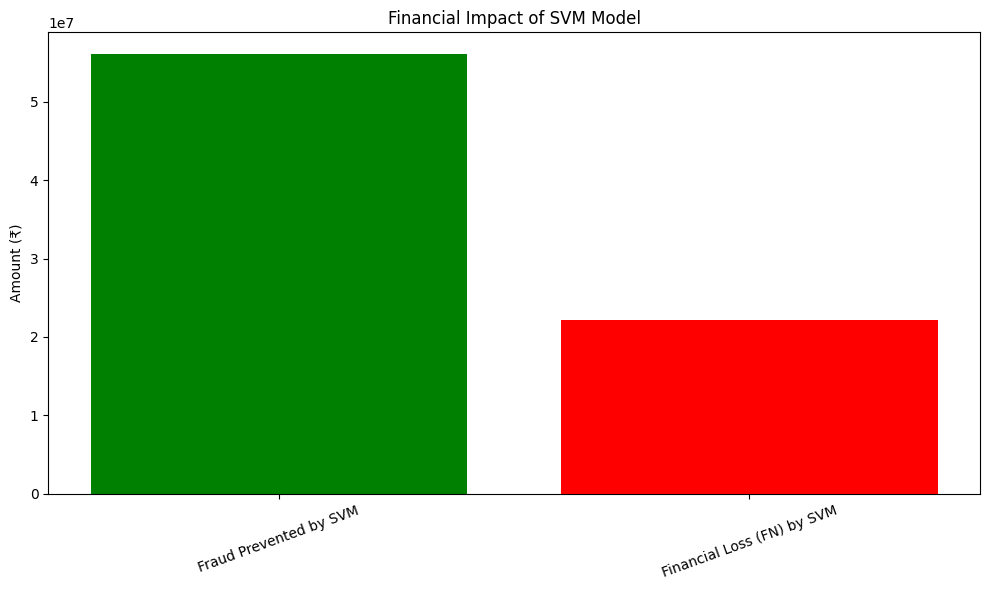

In [ ]:
# 11(C). Financial Impact Visualization

# Getting the financial data for the best performing model (SVM)
best_model_financials = financial_summary_df_sorted.iloc[0]
best_fraud_prevented = best_model_financials['Total Fraud Prevented (TP)']
best_financial_loss = best_model_financials['Total Financial Loss (FN)']
best_model_name = best_model_financials['Model']

financial_data = pd.DataFrame({
    "Category": [f"Fraud Prevented by {best_model_name}", f"Financial Loss (FN) by {best_model_name}"],
    "Amount": [best_fraud_prevented, best_financial_loss]
})

plt.figure(figsize=(10, 6))
plt.bar(financial_data["Category"], financial_data["Amount"], color=['green', 'red'])
plt.title(f"Financial Impact of {best_model_name} Model")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

/tmp/ipython-input-383/2905196661.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=log_feat_imp, palette='viridis')


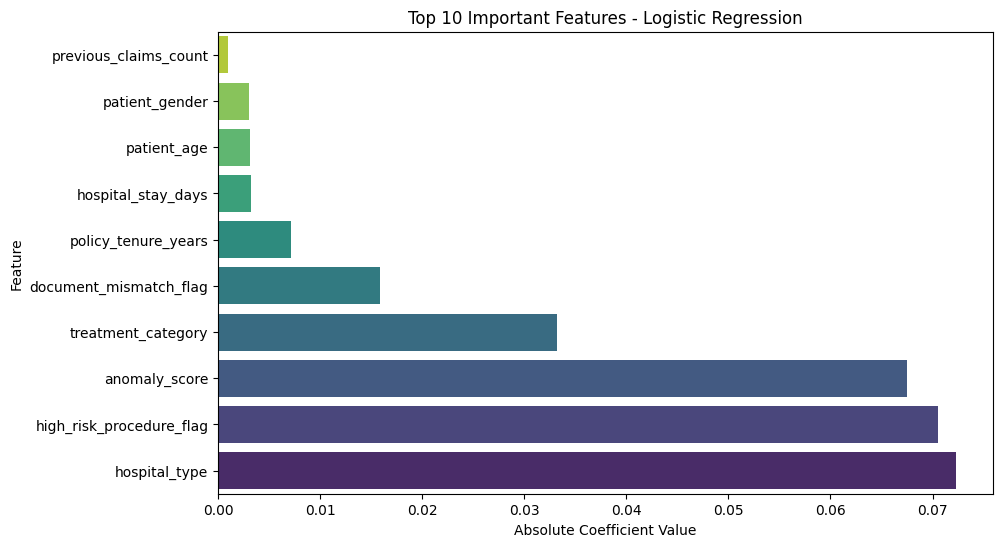

/tmp/ipython-input-383/2905196661.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=xgb_feat_imp, palette='viridis')


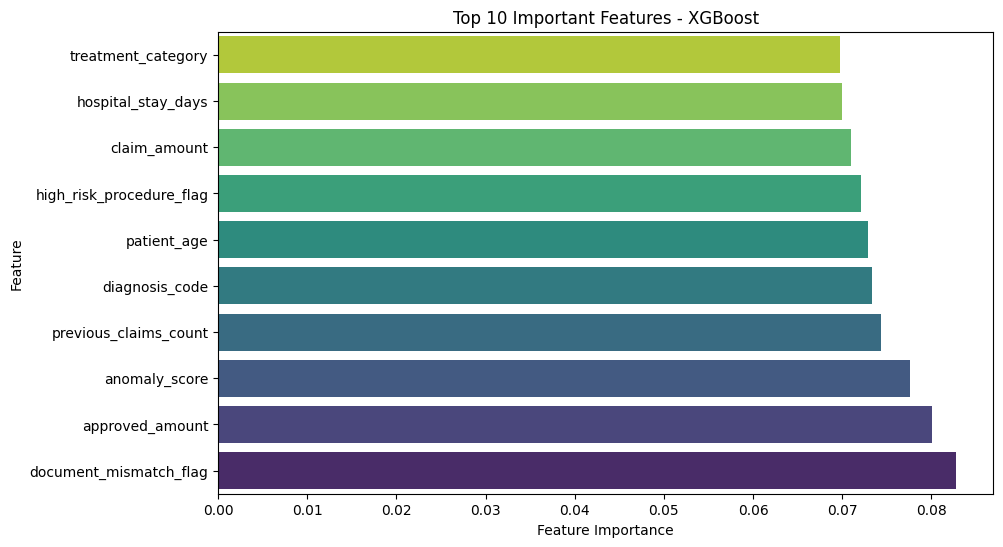

/tmp/ipython-input-383/2905196661.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=cat_feat_imp, palette='viridis')


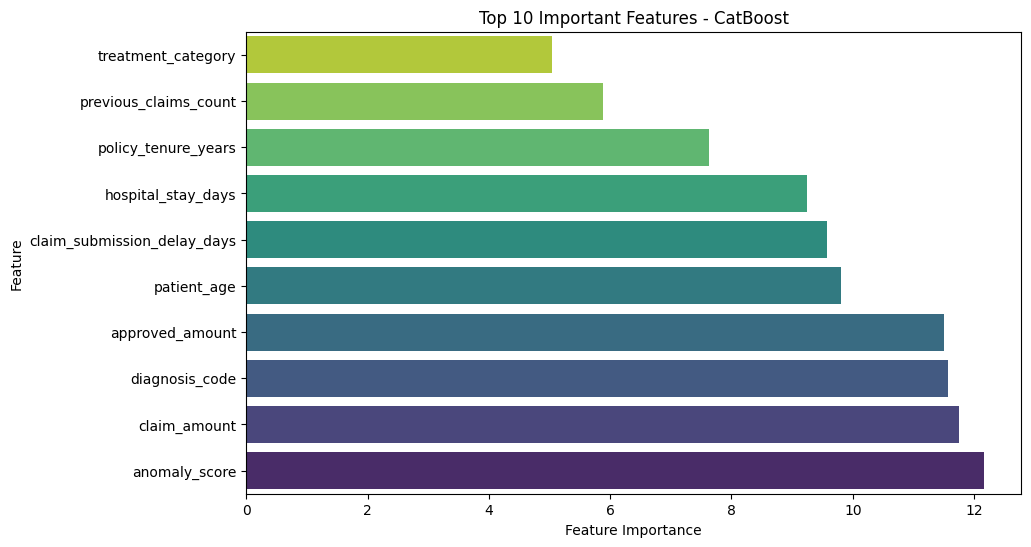

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 11(D). Feature Importance - Logistic Regression

# Get absolute coefficients
log_importances = np.abs(log_model.coef_[0])
feature_names = X_train.columns

log_feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": log_importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=log_feat_imp, palette='viridis')
plt.title("Top 10 Important Features - Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis() # Invert y-axis to show most important at top
plt.show()

# 11(D). Feature Importance - XGBoost

importances = xgb.feature_importances_
feature_names = X_train.columns

xgb_feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=xgb_feat_imp, palette='viridis')
plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# 11(D). Feature Importance - CatBoost

cat_importances = cat.get_feature_importance()
feature_names = X_train.columns

cat_feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cat_importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=cat_feat_imp, palette='viridis')
plt.title("Top 10 Important Features - CatBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis() # Invert y-axis to show most important at top
plt.show()

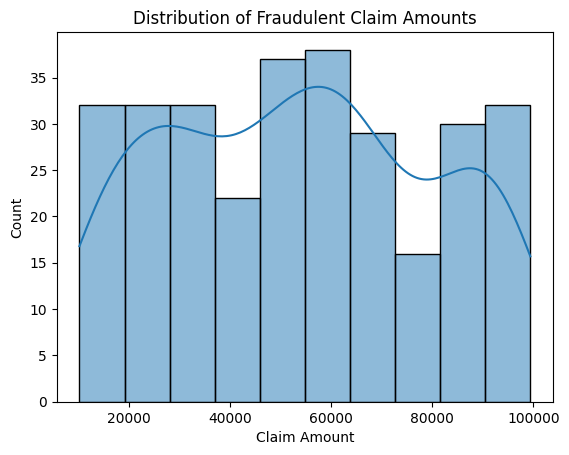

In [ ]:
# 11(E). Fraudulant Amount Detection

sns.histplot(
    X_test_copy[X_test_copy["Actual"] == 1]["claim_amount"],
    kde=True
)
plt.title("Distribution of Fraudulent Claim Amounts")
plt.xlabel("Claim Amount")
plt.show()

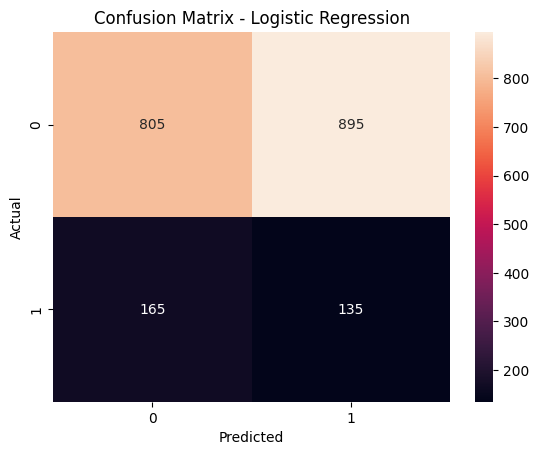

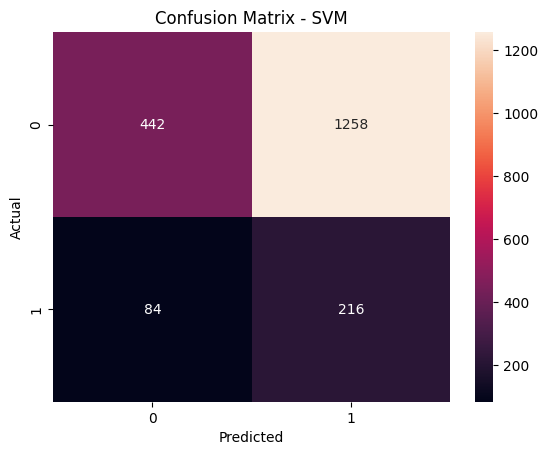

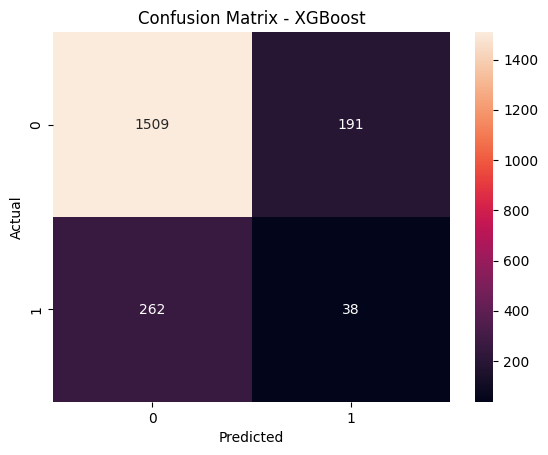

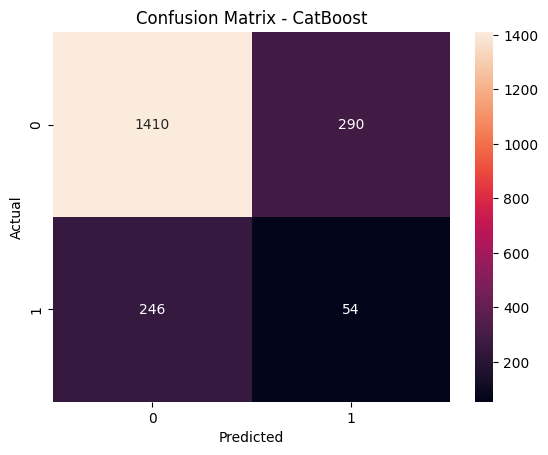

In [ ]:
# 11(F). Comparison Of The Confusion Matrices

from sklearn.metrics import confusion_matrix
import numpy as np

for name, model_pred_array in models_pred.items(): # Renamed 'model' to 'model_pred_array' to avoid confusion
    cm = confusion_matrix(y_test, model_pred_array)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

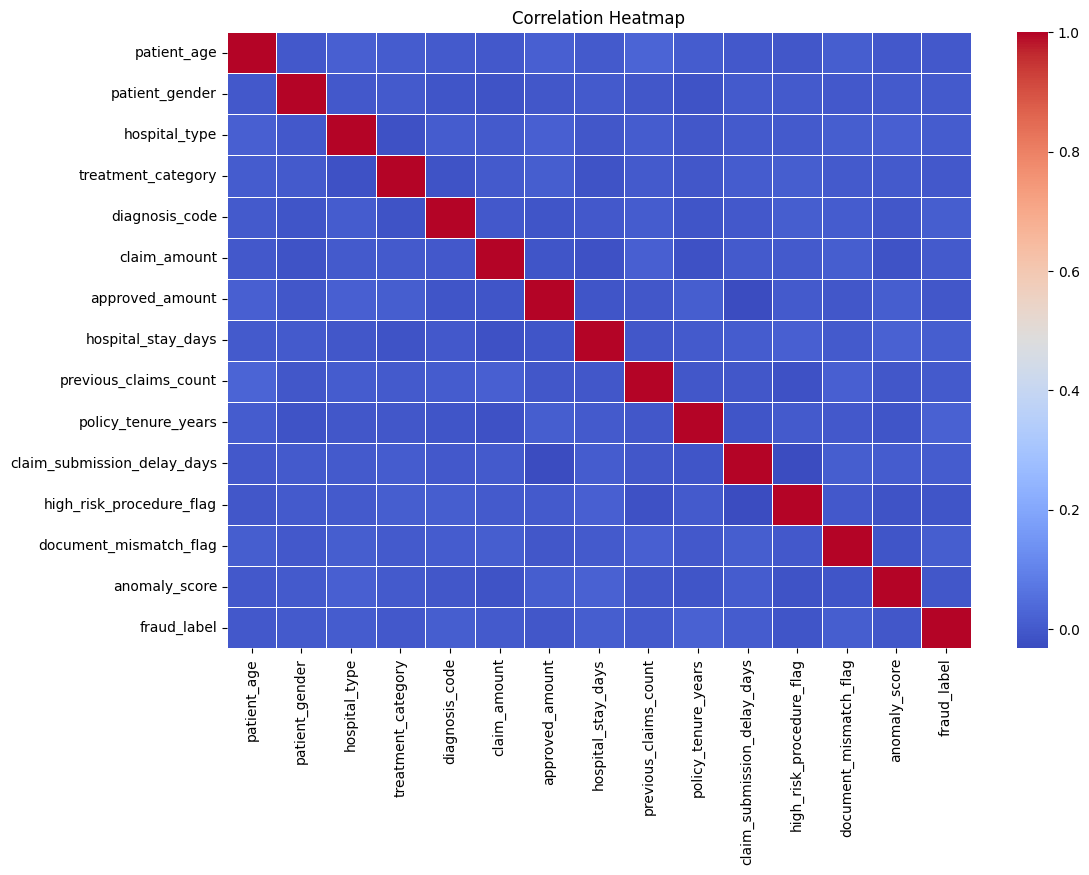

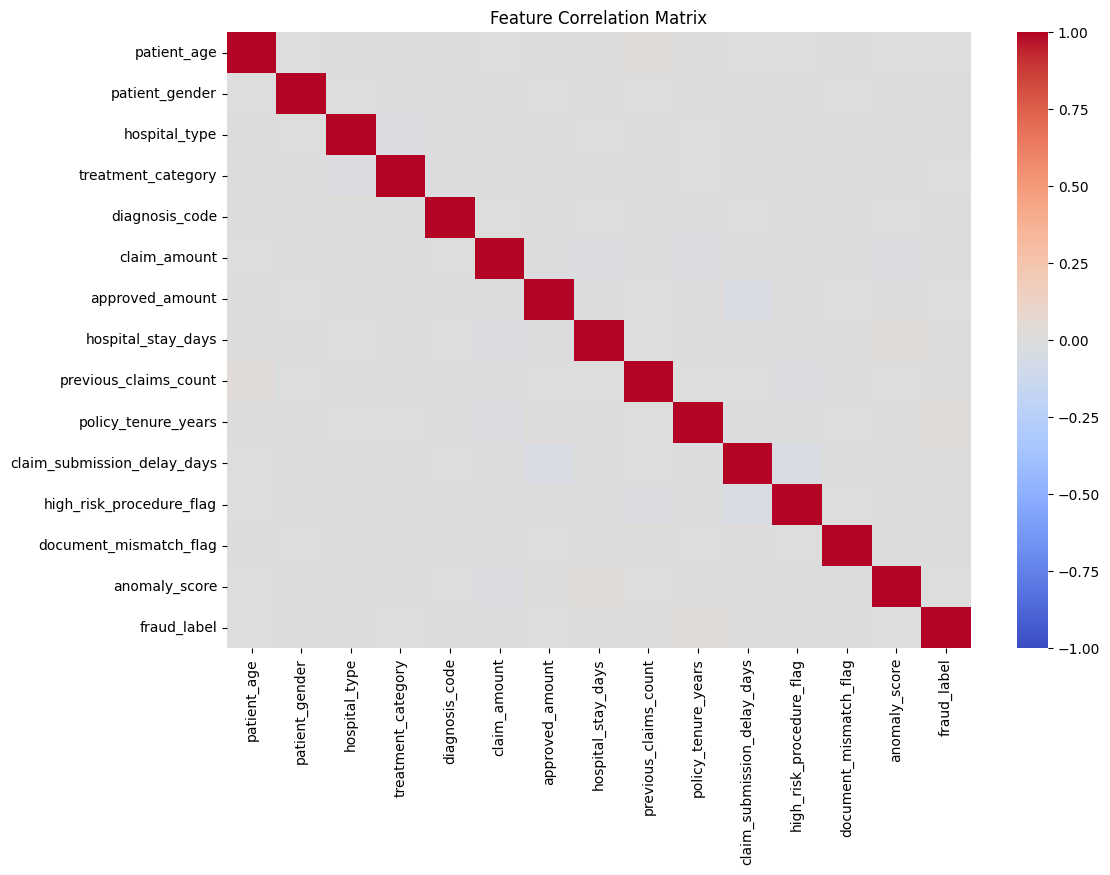

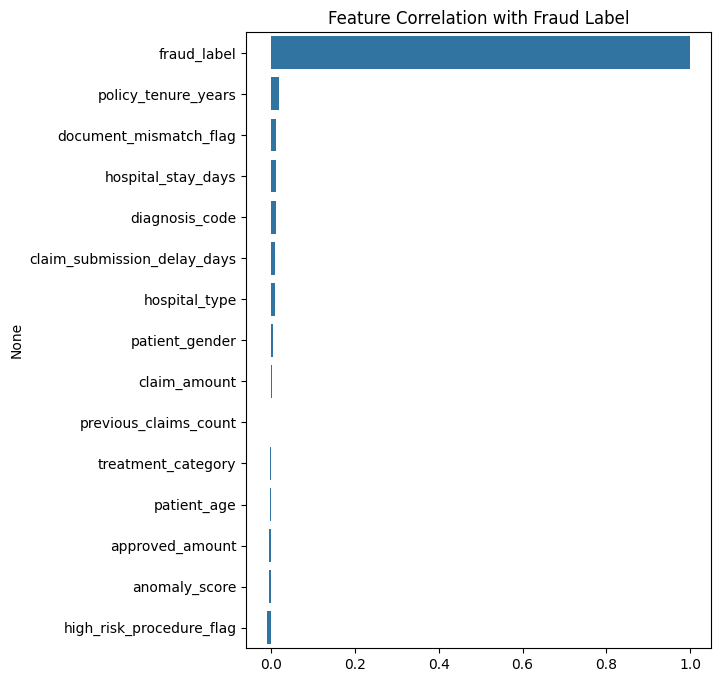

In [ ]:
# 11(G). Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Feature Correlation Matrix")
plt.show()

target_corr = corr_matrix["fraud_label"].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Feature Correlation with Fraud Label")
plt.show()

***Step-12: Final Model Selection***

Based on the financial impact analysis where SVM demonstrated the highest total fraud prevented, this model is selected as the final model.

## **Summary:**

The updated model performance and financial impact are summarized as follows:

*   **Model Performance Comparison**:
    *   **SVM** demonstrates the highest Recall at 0.72, making it the most effective model for identifying actual fraudulent claims.
    *   **Logistic Regression** has a Recall of 0.45.
    *   **CatBoost** and **XGBoost** show lower Recall values of 0.18 and 0.12, respectively.
    *   Precision scores remain generally low across all models, indicating a tendency for false positives.

*   **Financial Impact Analysis**:
    *   **SVM** is the leading model in fraud prevention, preventing \$56,052,324.94 in fraud while incurring \$22,222,707.58 in financial loss due to false negatives.
    *   **Logistic Regression** prevents \$31,467,622.68 in fraud, with a financial loss of \$46,807,409.84.
    *   **CatBoost** prevents \$14,898,623.97 in fraud, with a financial loss of \$63,376,408.55.
    *   **XGBoost** prevents \$9,387,141.68 in fraud, with a financial loss of \$68,887,890.84.

###**Key Findings obtained from Data Analysis :**

*   **SVM** consistently outperformed other models in terms of Recall (0.72) and financial fraud prevention, preventing \$56,052,324.94 in fraud, significantly higher than the next best, Logistic Regression (\$31,467,622.68).
*   All models, including SVM, exhibit relatively low precision scores, indicating a challenge in minimizing false positives, even while identifying actual fraud.
*   The feature importance visualization was updated to reflect the 'XGBoost' model's top 10 influential features, providing insights into its decision-making process.


